## 1. Initial Data Loading and Inspection

In [1]:
import pandas as pd

# Load the first CSV file into df1
df1 = pd.read_csv('/content/new.csv')
print("DataFrame 1 (from 'new.csv'):")
display(df1.head())

# Load the second CSV file into df2
df2 = pd.read_csv('/content/qs.csv')
print("\nDataFrame 2 (from 'qs.csv'):")
display(df2.head())

DataFrame 1 (from 'new.csv'):


,ID,Tier,Region,Jurisdiction / Institution,Institution,Document Title,Document Type,Publication Date,Source URL,Stance,...,Focus (Secondary),Enforcement,Coverage,Key Quote (verbatim),Coder Notes,Coder,Date Coded,Stance #,Tier #,Governance Domain
0,NYC-001,National/Federal,NYC,US Federal (White House),NaN,National Policy Framework for Artificial Intel...,Executive Order,12/20/2026,https://www.whitehouse.gov/wp-content/uploads/...,Functional,...,AI Literacy,Guidance only,Whole community,“The federal government must establish a feder...,NaN,EY,05/15,2,1,External
1,NYC-002,National/Federal,NYC,US Federal (White House),NaN,Executive Order: Eliminating State Law Obstruc...,Executive Order,11/12/2025,https://www.whitehouse.gov/presidential-action...,Encouraging,...,AI Literacy,Guidance only,Whole community,It is the policy of the United States to sust...,NaN,EY,05/15,3,1,External
2,NYC-003,National/Federal,NYC,ACUS (Administrative Conference of the United ...,NaN,ACUS Policy on Use of Generative AI,Law/Regulation,10/12/2025,https://www.acus.gov/sites/default/files/docum...,Cautious,...,Academic Integrity,Referenced to integrity code,Whole community,Federal employees must disclose GenAI use and ...,NaN,EY,05/15,1,1,External
3,NYC-004,National/Federal,NYC,US Federal (White House),NaN,Advancing Artificial Intelligence Education fo...,Executive Order,4/23/2025,https://www.whitehouse.gov/presidential-action...,Encouraging,...,Pedagogy/Learning,Guidance only,Whole community,“It is the policy of the United States to prom...,NaN,EY,05/15,3,1,External
4,NYC-005,National/Federal,NYC,US Federal (White House),NaN,Ensuring a National Policy Framework for AI,Executive Order,12/11/2025,https://www.whitehouse.gov/presidential-action...,Encouraging,...,Privacy/Data/Ethics,Explicit penalties,Whole community,“United States AI companies must be free to in...,NaN,EY,05/15,3,1,External



DataFrame 2 (from 'qs.csv'):


,Region,Institution,QS (2026),QS Size Class,Total Faculty Staff,Syllabus (raw),With AI statements,%,Unnamed: 8
0,NYC,Columbia,38,XL,8194,6,6,100.0%,NaN
1,NYC,NYU,55,XL,7538,6,6,100.0%,NaN
2,NYC,CUNY,613,XL,7782,5,5,100.0%,NaN
3,HK,HKU,11,L,2608,4,3,75.0%,NaN
4,HK,PolyU,54,L,2745,6,1,16.7%,NaN


### 1.1 Data Cleaning: Removing Unnecessary Columns

In [2]:
if 'Unnamed: 8' in df2.columns:
    df2 = df2.drop(columns=['Unnamed: 8'])
    print("Dropped 'Unnamed: 8' from df2.")
    display(df2.head())
else:
    print("'Unnamed: 8' column not found in df2.")

Dropped 'Unnamed: 8' from df2.


,Region,Institution,QS (2026),QS Size Class,Total Faculty Staff,Syllabus (raw),With AI statements,%
0,NYC,Columbia,38,XL,8194,6,6,100.0%
1,NYC,NYU,55,XL,7538,6,6,100.0%
2,NYC,CUNY,613,XL,7782,5,5,100.0%
3,HK,HKU,11,L,2608,4,3,75.0%
4,HK,PolyU,54,L,2745,6,1,16.7%


### 1.2 Data Cleaning: Standardizing 'Discretion' Categories

In [3]:
# Standardize 'Discretion' categories
df1['Discretion'] = df1['Discretion'].replace('Faculty/Dept decides', 'Faculty/Department decides')

print("--- Corrected 'Discretion' categories in df1 ---")
print(df1['Discretion'].value_counts().sort_index())


--- Corrected 'Discretion' categories in df1 ---
Discretion
Faculty/Department decides     4
Gov-mandated                  19
Hybrid                        20
Institution-mandated          21
Instructor decides            38
Not specified                  8
Name: count, dtype: int64


### 1.3 Data Merging

In [4]:
# Merge df1 and df2 on 'Region' and 'Institution'
merged_df = pd.merge(df1, df2, on=['Region', 'Institution'], how='left')

print("Merged DataFrame (first 5 rows):")
display(merged_df.head())

Merged DataFrame (first 5 rows):


,ID,Tier,Region,Jurisdiction / Institution,Institution,Document Title,Document Type,Publication Date,Source URL,Stance,...,Date Coded,Stance #,Tier #,Governance Domain,QS (2026),QS Size Class,Total Faculty Staff,Syllabus (raw),With AI statements,%
0,NYC-001,National/Federal,NYC,US Federal (White House),NaN,National Policy Framework for Artificial Intel...,Executive Order,12/20/2026,https://www.whitehouse.gov/wp-content/uploads/...,Functional,...,05/15,2,1,External,NaN,NaN,NaN,NaN,NaN,NaN
1,NYC-002,National/Federal,NYC,US Federal (White House),NaN,Executive Order: Eliminating State Law Obstruc...,Executive Order,11/12/2025,https://www.whitehouse.gov/presidential-action...,Encouraging,...,05/15,3,1,External,NaN,NaN,NaN,NaN,NaN,NaN
2,NYC-003,National/Federal,NYC,ACUS (Administrative Conference of the United ...,NaN,ACUS Policy on Use of Generative AI,Law/Regulation,10/12/2025,https://www.acus.gov/sites/default/files/docum...,Cautious,...,05/15,1,1,External,NaN,NaN,NaN,NaN,NaN,NaN
3,NYC-004,National/Federal,NYC,US Federal (White House),NaN,Advancing Artificial Intelligence Education fo...,Executive Order,4/23/2025,https://www.whitehouse.gov/presidential-action...,Encouraging,...,05/15,3,1,External,NaN,NaN,NaN,NaN,NaN,NaN
4,NYC-005,National/Federal,NYC,US Federal (White House),NaN,Ensuring a National Policy Framework for AI,Executive Order,12/11/2025,https://www.whitehouse.gov/presidential-action...,Encouraging,...,05/15,3,1,External,NaN,NaN,NaN,NaN,NaN,NaN


### 1.4 Column Filtering for Analysis

In [5]:
selected_columns = [
    'ID', 'Tier', 'Region', 'Institution', 'Document Type',
    'Stance', 'Disclosure', 'Discretion', 'Focus (Primary)',
    'Enforcement', 'Coverage'
]

filtered_df = merged_df[selected_columns].copy()

print("Filtered DataFrame (first 5 rows with selected columns):")
display(filtered_df.head())

Filtered DataFrame (first 5 rows with selected columns):


,ID,Tier,Region,Institution,Document Type,Stance,Disclosure,Discretion,Focus (Primary),Enforcement,Coverage
0,NYC-001,National/Federal,NYC,NaN,Executive Order,Functional,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community
1,NYC-002,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community
2,NYC-003,National/Federal,NYC,NaN,Law/Regulation,Cautious,Required,Gov-mandated,Privacy/Data/Ethics,Referenced to integrity code,Whole community
3,NYC-004,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community
4,NYC-005,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Explicit penalties,Whole community


### 1.5 Filtering Out 'Not Specified' Stances

In [6]:
# Exclude rows where 'Stance' is 'Not specified'
filtered_df = filtered_df[filtered_df['Stance'] != 'Not specified'].copy()

print("Filtered DataFrame after excluding 'Not specified' stance (first 5 rows):")
display(filtered_df.head())

Filtered DataFrame after excluding 'Not specified' stance (first 5 rows):


,ID,Tier,Region,Institution,Document Type,Stance,Disclosure,Discretion,Focus (Primary),Enforcement,Coverage
0,NYC-001,National/Federal,NYC,NaN,Executive Order,Functional,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community
1,NYC-002,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community
2,NYC-003,National/Federal,NYC,NaN,Law/Regulation,Cautious,Required,Gov-mandated,Privacy/Data/Ethics,Referenced to integrity code,Whole community
3,NYC-004,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community
4,NYC-005,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Explicit penalties,Whole community


### 1.6 Regional Counts

In [7]:
region_counts = filtered_df.groupby('Region').size().reset_index(name='Count')

print("Counts grouped by Region:")
display(region_counts)

Counts grouped by Region:


,Region,Count
0,Hong Kong,55
1,NYC,55


### 1.7 Creating Numeric 'Tier' and 'Stance' Columns

In [8]:
# Define the mapping for Tier
tier_mapping = {
    'National/Federal': 1,
    'City/Territory': 2,
    'Institutional': 3,
    'Faculty/Department': 4,
    'Course-wide': 5
}

# Define the mapping for Stance
stance_mapping = {
    'Prohibitive': 0,
    'Cautious': 1,
    'Functional': 2,
    'Encouraging': 3
    # 'Not specified' is expected to be removed, so no mapping needed
}

# Create new numeric columns
filtered_df['Tier_Numeric'] = filtered_df['Tier'].map(tier_mapping)
filtered_df['Stance_Numeric'] = filtered_df['Stance'].map(stance_mapping)

print("Filtered DataFrame with new numeric 'Tier' and 'Stance' columns (first 5 rows):")
display(filtered_df.head())

Filtered DataFrame with new numeric 'Tier' and 'Stance' columns (first 5 rows):


,ID,Tier,Region,Institution,Document Type,Stance,Disclosure,Discretion,Focus (Primary),Enforcement,Coverage,Tier_Numeric,Stance_Numeric
0,NYC-001,National/Federal,NYC,NaN,Executive Order,Functional,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community,1,2
1,NYC-002,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community,1,3
2,NYC-003,National/Federal,NYC,NaN,Law/Regulation,Cautious,Required,Gov-mandated,Privacy/Data/Ethics,Referenced to integrity code,Whole community,1,1
3,NYC-004,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community,1,3
4,NYC-005,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Explicit penalties,Whole community,1,3


## 2. Overall Regional Differences in Stance

In [9]:
reversed_tier_mapping = {v: k for k, v in tier_mapping.items()}

### 2.1 Two-Way ANOVA: Stance by Tier, Region, and Interaction

In [10]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Ensure there are no NaNs in the relevant columns for the ANOVA
anova_df_full = filtered_df.dropna(subset=['Stance_Numeric', 'Tier_Numeric', 'Region']).copy()

# Perform Two-Way ANOVA
# The formula specifies Stance_Numeric as the dependent variable,
# and Tier_Numeric, Region, and their interaction as independent variables.
# C() is used to treat Tier_Numeric and Region as categorical factors.
model_formula_full_anova = 'Stance_Numeric ~ C(Tier_Numeric) + C(Region) + C(Tier_Numeric):C(Region)'

anova_model_full = smf.ols(model_formula_full_anova, data=anova_df_full).fit()

# Print the ANOVA table
print("\n--- Two-Way ANOVA Results (Stance ~ Tier + Region + Interaction) ---")
display(sm.stats.anova_lm(anova_model_full, typ=2))

print("\n--- Interpretation ---")
print("1. C(Tier_Numeric): Checks if there's a significant difference in Stance across different Tier levels, averaged across regions.")
print("2. C(Region): Checks if there's a significant difference in Stance between regions (NYC vs. Hong Kong), averaged across tiers.")
print("3. C(Tier_Numeric):C(Region): Checks for an interaction effect. A significant interaction means the effect of Tier on Stance is different depending on the Region.")
print("   Look at the 'PR(>F)' (p-value) for each term. If it's less than 0.05, the effect is considered statistically significant.")


--- Two-Way ANOVA Results (Stance ~ Tier + Region + Interaction) ---


,sum_sq,df,F,PR(>F)
C(Tier_Numeric),15.151515,4.0,5.716115,0.000348
C(Region),8.736364,1.0,13.183647,0.000447
C(Tier_Numeric):C(Region),9.563636,4.0,3.608012,0.008636
Residual,66.266667,100.0,NaN,NaN



--- Interpretation ---
1. C(Tier_Numeric): Checks if there's a significant difference in Stance across different Tier levels, averaged across regions.
2. C(Region): Checks if there's a significant difference in Stance between regions (NYC vs. Hong Kong), averaged across tiers.
3. C(Tier_Numeric):C(Region): Checks for an interaction effect. A significant interaction means the effect of Tier on Stance is different depending on the Region.
   Look at the 'PR(>F)' (p-value) for each term. If it's less than 0.05, the effect is considered statistically significant.


### 2.2 Statistical Significance for Stance ~ Tier + Region (Custom Effect Coded) + Interaction

In [11]:
print("Current state of df1:")
display(df1.head())

print("\nCurrent state of df2:")
display(df2.head())

print("\nCurrent state of filtered_df:")
display(filtered_df.head())

Current state of df1:


,ID,Tier,Region,Jurisdiction / Institution,Institution,Document Title,Document Type,Publication Date,Source URL,Stance,...,Focus (Secondary),Enforcement,Coverage,Key Quote (verbatim),Coder Notes,Coder,Date Coded,Stance #,Tier #,Governance Domain
0,NYC-001,National/Federal,NYC,US Federal (White House),NaN,National Policy Framework for Artificial Intel...,Executive Order,12/20/2026,https://www.whitehouse.gov/wp-content/uploads/...,Functional,...,AI Literacy,Guidance only,Whole community,“The federal government must establish a feder...,NaN,EY,05/15,2,1,External
1,NYC-002,National/Federal,NYC,US Federal (White House),NaN,Executive Order: Eliminating State Law Obstruc...,Executive Order,11/12/2025,https://www.whitehouse.gov/presidential-action...,Encouraging,...,AI Literacy,Guidance only,Whole community,It is the policy of the United States to sust...,NaN,EY,05/15,3,1,External
2,NYC-003,National/Federal,NYC,ACUS (Administrative Conference of the United ...,NaN,ACUS Policy on Use of Generative AI,Law/Regulation,10/12/2025,https://www.acus.gov/sites/default/files/docum...,Cautious,...,Academic Integrity,Referenced to integrity code,Whole community,Federal employees must disclose GenAI use and ...,NaN,EY,05/15,1,1,External
3,NYC-004,National/Federal,NYC,US Federal (White House),NaN,Advancing Artificial Intelligence Education fo...,Executive Order,4/23/2025,https://www.whitehouse.gov/presidential-action...,Encouraging,...,Pedagogy/Learning,Guidance only,Whole community,“It is the policy of the United States to prom...,NaN,EY,05/15,3,1,External
4,NYC-005,National/Federal,NYC,US Federal (White House),NaN,Ensuring a National Policy Framework for AI,Executive Order,12/11/2025,https://www.whitehouse.gov/presidential-action...,Encouraging,...,Privacy/Data/Ethics,Explicit penalties,Whole community,“United States AI companies must be free to in...,NaN,EY,05/15,3,1,External



Current state of df2:


,Region,Institution,QS (2026),QS Size Class,Total Faculty Staff,Syllabus (raw),With AI statements,%
0,NYC,Columbia,38,XL,8194,6,6,100.0%
1,NYC,NYU,55,XL,7538,6,6,100.0%
2,NYC,CUNY,613,XL,7782,5,5,100.0%
3,HK,HKU,11,L,2608,4,3,75.0%
4,HK,PolyU,54,L,2745,6,1,16.7%



Current state of filtered_df:


,ID,Tier,Region,Institution,Document Type,Stance,Disclosure,Discretion,Focus (Primary),Enforcement,Coverage,Tier_Numeric,Stance_Numeric
0,NYC-001,National/Federal,NYC,NaN,Executive Order,Functional,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community,1,2
1,NYC-002,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community,1,3
2,NYC-003,National/Federal,NYC,NaN,Law/Regulation,Cautious,Required,Gov-mandated,Privacy/Data/Ethics,Referenced to integrity code,Whole community,1,1
3,NYC-004,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community,1,3
4,NYC-005,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Explicit penalties,Whole community,1,3


In [12]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Drop rows with NaN values in 'Tier_Numeric', 'Stance_Numeric', or 'Region'
# We use 'filtered_df' as the base DataFrame for this analysis
model_df_custom_coded = filtered_df.dropna(subset=['Tier_Numeric', 'Stance_Numeric', 'Region']).copy()

# Create a new column for effect coding of 'Region'
# NYC = -1, Hong Kong = 1
model_df_custom_coded['Region_Effect_Coded_User'] = model_df_custom_coded['Region'].apply(lambda x: -1 if x == 'NYC' else 1)

# Create the interaction term: Tier_Numeric * Region_Effect_Coded_User
model_df_custom_coded['Tier_Numeric_x_Region_Effect_Coded_User'] = \
    model_df_custom_coded['Tier_Numeric'] * model_df_custom_coded['Region_Effect_Coded_User']

# Define features (X) and target (y)
X_custom = model_df_custom_coded[['Tier_Numeric', 'Region_Effect_Coded_User', 'Tier_Numeric_x_Region_Effect_Coded_User']]
y_custom = model_df_custom_coded['Stance_Numeric']

# Add a constant to the independent variable (X) for the intercept term
X_custom_sm = sm.add_constant(X_custom)

# Create and fit the OLS model
model_sm_custom_coded = sm.OLS(y_custom, X_custom_sm)
results_sm_custom_coded = model_sm_custom_coded.fit()

# Print the model summary
print("\n--- Statistical Significance for Stance ~ Tier + Region (Custom Effect Coded) + Interaction ---")
print(results_sm_custom_coded.summary())

# Display the first few rows of the DataFrame with the new effect-coded column
print("\nDataFrame with new 'Region_Effect_Coded_User' column (first 5 rows):")
display(model_df_custom_coded.head())


--- Statistical Significance for Stance ~ Tier + Region (Custom Effect Coded) + Interaction ---
                            OLS Regression Results                            
Dep. Variable:         Stance_Numeric   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     10.52
Date:                Sun, 17 May 2026   Prob (F-statistic):           4.09e-06
Time:                        02:08:42   Log-Likelihood:                -136.35
No. Observations:                 110   AIC:                             280.7
Df Residuals:                     106   BIC:                             291.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----

,ID,Tier,Region,Institution,Document Type,Stance,Disclosure,Discretion,Focus (Primary),Enforcement,Coverage,Tier_Numeric,Stance_Numeric,Region_Effect_Coded_User,Tier_Numeric_x_Region_Effect_Coded_User
0,NYC-001,National/Federal,NYC,NaN,Executive Order,Functional,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community,1,2,-1,-1
1,NYC-002,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community,1,3,-1,-1
2,NYC-003,National/Federal,NYC,NaN,Law/Regulation,Cautious,Required,Gov-mandated,Privacy/Data/Ethics,Referenced to integrity code,Whole community,1,1,-1,-1
3,NYC-004,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Guidance only,Whole community,1,3,-1,-1
4,NYC-005,National/Federal,NYC,NaN,Executive Order,Encouraging,Not specified,Gov-mandated,Professional Readiness,Explicit penalties,Whole community,1,3,-1,-1


### 2.3 Statistical Significance for Stance ~ Tier + Region (Custom Effect Coded, Main Effects Only)

In [13]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Ensure filtered_df is available and properly preprocessed
# Drop rows with NaN values in 'Tier_Numeric', 'Stance_Numeric', or 'Region'
model_df_main_effects = filtered_df.dropna(subset=['Tier_Numeric', 'Stance_Numeric', 'Region']).copy()

# Create a new column for custom effect coding of 'Region'
# NYC = -1, Hong Kong = 1
model_df_main_effects['Region_Effect_Coded_User'] = model_df_main_effects['Region'].apply(lambda x: -1 if x == 'NYC' else 1)

# Define features (X) and target (y) for the main effects model
# Exclude the interaction term here
X_main_effects = model_df_main_effects[['Tier_Numeric', 'Region_Effect_Coded_User']]
y_main_effects = model_df_main_effects['Stance_Numeric']

# Add a constant to the independent variable (X) for the intercept term
X_main_effects_sm = sm.add_constant(X_main_effects)

# Create and fit the OLS model for main effects only
model_sm_main_effects = sm.OLS(y_main_effects, X_main_effects_sm)
results_sm_main_effects = model_sm_main_effects.fit()

# Print the model summary
print("\n--- Statistical Significance for Stance ~ Tier + Region (Custom Effect Coded, Main Effects Only) ---")
print(results_sm_main_effects.summary())

print("\n--- Interpretation ---")
print("1. 'const' (Intercept): Represents the expected Stance_Numeric when both Tier_Numeric and Region_Effect_Coded_User are zero (though effect-coded variables don't strictly have a 'zero' point easily interpretable as the baseline). It's the predicted Stance_Numeric for an average Tier and the reference Region.")
print("2. 'Tier_Numeric': Shows the change in Stance_Numeric for a one-unit increase in Tier_Numeric, holding Region constant. A negative coefficient means as Tier_Numeric increases (from National/Federal to Course-wide), Stance_Numeric tends to decrease (from Encouraging to Prohibitive).")
print("3. 'Region_Effect_Coded_User': Represents the difference in Stance_Numeric between the effect-coded regions, holding Tier_Numeric constant. Since NYC is -1 and Hong Kong is 1, a positive coefficient would mean Stance_Numeric is higher in Hong Kong than NYC (for a given Tier), and a negative coefficient means it's lower in Hong Kong than NYC.")
print("   Look at the 'P>|t|' (p-value) for each term. If it's less than 0.05, the effect is considered statistically significant.")



--- Statistical Significance for Stance ~ Tier + Region (Custom Effect Coded, Main Effects Only) ---
                            OLS Regression Results                            
Dep. Variable:         Stance_Numeric   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     15.93
Date:                Sun, 17 May 2026   Prob (F-statistic):           8.80e-07
Time:                        02:08:42   Log-Likelihood:                -136.35
No. Observations:                 110   AIC:                             278.7
Df Residuals:                     107   BIC:                             286.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------

### 2.4 Mann-Whitney U Test for Regional Differences

### Mann-Whitney U Test for Regional Differences

To further investigate the difference in 'Stance_Numeric' between the two regions, we can perform a Mann-Whitney U test. This is a non-parametric test that compares the medians of two independent groups and is suitable for ordinal data or when the assumption of normality for a t-test cannot be met.

-   **Null Hypothesis (H0)**: There is no difference in the distribution of 'Stance_Numeric' between NYC and Hong Kong.
-   **Alternative Hypothesis (H1)**: There is a difference in the distribution of 'Stance_Numeric' between NYC and Hong Kong.

### Answering: "Regardless of Tier, is one region generally more 'Encouraging' than the other?"

In [14]:
# Re-display the summary of the main effects model
print(results_sm_main_effects.summary())

print("\n--- Interpretation for Regional Difference ---")
print("The key to answering your question lies in the 'Region_Effect_Coded_User' row of the coefficient table:")
print("  - **Coefficient (coef)**: This value indicates the average difference in 'Stance_Numeric' when moving from NYC (coded as -1) to Hong Kong (coded as 1), after accounting for the 'Tier_Numeric'. A positive coefficient means Hong Kong is generally more encouraging, and a negative coefficient means NYC is.")
print("  - **P-value (P>|t|)**: This tells you if the observed difference is statistically significant. If this P-value is less than 0.05, we can conclude with reasonable confidence that there is a statistically significant difference in 'Stance_Numeric' between the regions, regardless of Tier.")
print("\nBased on the output:")
print(f"  - The coefficient for 'Region_Effect_Coded_User' is {results_sm_main_effects.params['Region_Effect_Coded_User']:.3f}.")
print(f"  - The P-value for 'Region_Effect_Coded_User' is {results_sm_main_effects.pvalues['Region_Effect_Coded_User']:.3f}.")
print("  - Evaluate the P-value to determine statistical significance.")

                            OLS Regression Results                            
Dep. Variable:         Stance_Numeric   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     15.93
Date:                Sun, 17 May 2026   Prob (F-statistic):           8.80e-07
Time:                        02:08:43   Log-Likelihood:                -136.35
No. Observations:                 110   AIC:                             278.7
Df Residuals:                     107   BIC:                             286.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [15]:
from scipy.stats import mannwhitneyu

# Separate 'Stance_Numeric' data for each region
nyc_stance = filtered_df[filtered_df['Region'] == 'NYC']['Stance_Numeric'].dropna()
hk_stance = filtered_df[filtered_df['Region'] == 'Hong Kong']['Stance_Numeric'].dropna()

# Perform the Mann-Whitney U test
statistic, p_value = mannwhitneyu(nyc_stance, hk_stance, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {statistic:.3f}")
print(f"P-value: {p_value:.3f}")

print("\n--- Interpretation ---")
if p_value < 0.05:
    print(f"Since the P-value ({p_value:.3f}) is less than 0.05, we reject the null hypothesis.")
    print("This suggests a statistically significant difference in the distribution of 'Stance_Numeric' between NYC and Hong Kong.")

    # To determine which region is 'more encouraging', we can compare their medians or means
    nyc_median = nyc_stance.median()
    hk_median = hk_stance.median()
    print(f"Median 'Stance_Numeric' for NYC: {nyc_median}")
    print(f"Median 'Stance_Numeric' for Hong Kong: {hk_median}")

    if hk_median > nyc_median:
        print("Hong Kong tends to have a higher 'Stance_Numeric' (more encouraging) compared to NYC.")
    elif nyc_median > hk_median:
        print("NYC tends to have a higher 'Stance_Numeric' (more encouraging) compared to Hong Kong.")
    else:
        print("The medians are similar, but the distributions are significantly different.")
else:
    print(f"Since the P-value ({p_value:.3f}) is greater than or equal to 0.05, we fail to reject the null hypothesis.")
    print("This suggests there is no statistically significant difference in the distribution of 'Stance_Numeric' between NYC and Hong Kong.")

Mann-Whitney U Statistic: 1044.000
P-value: 0.003

--- Interpretation ---
Since the P-value (0.003) is less than 0.05, we reject the null hypothesis.
This suggests a statistically significant difference in the distribution of 'Stance_Numeric' between NYC and Hong Kong.
Median 'Stance_Numeric' for NYC: 1.0
Median 'Stance_Numeric' for Hong Kong: 2.0
Hong Kong tends to have a higher 'Stance_Numeric' (more encouraging) compared to NYC.


### 2.5 Visualization of Stance_Numeric Distribution by Region

### Visualization of Stance_Numeric Distribution by Region

To visually inspect the differences confirmed by the statistical tests, a boxplot can effectively display the distribution of 'Stance_Numeric' for each region.

/tmp/ipykernel_2584/875475772.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Stance_Numeric', data=filtered_df, palette='viridis', order=['Hong Kong', 'NYC'])


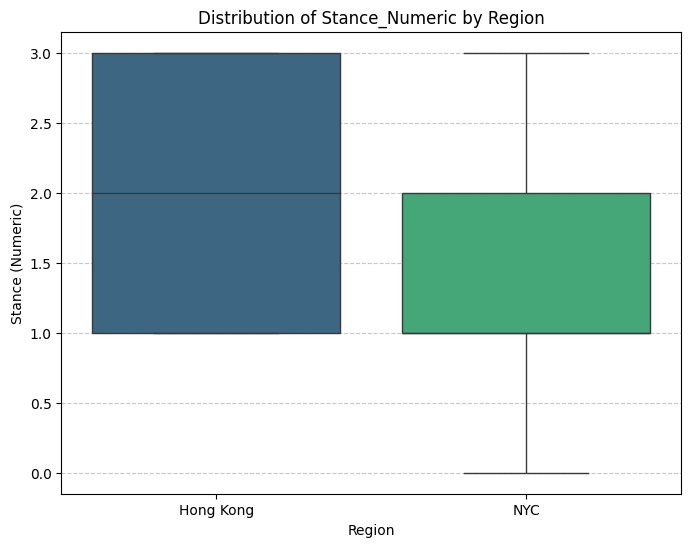

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Region', y='Stance_Numeric', data=filtered_df, palette='viridis', order=['Hong Kong', 'NYC'])
plt.title('Distribution of Stance_Numeric by Region')
plt.xlabel('Region')
plt.ylabel('Stance (Numeric)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2.6 100% Stacked Bar Chart of 'Stance_Numeric' by Region

### 100% Stacked Bar Chart of 'Stance_Numeric' by Region

This chart will show the proportion of each 'Stance_Numeric' category within NYC and Hong Kong, allowing for a direct comparison of their compositions.

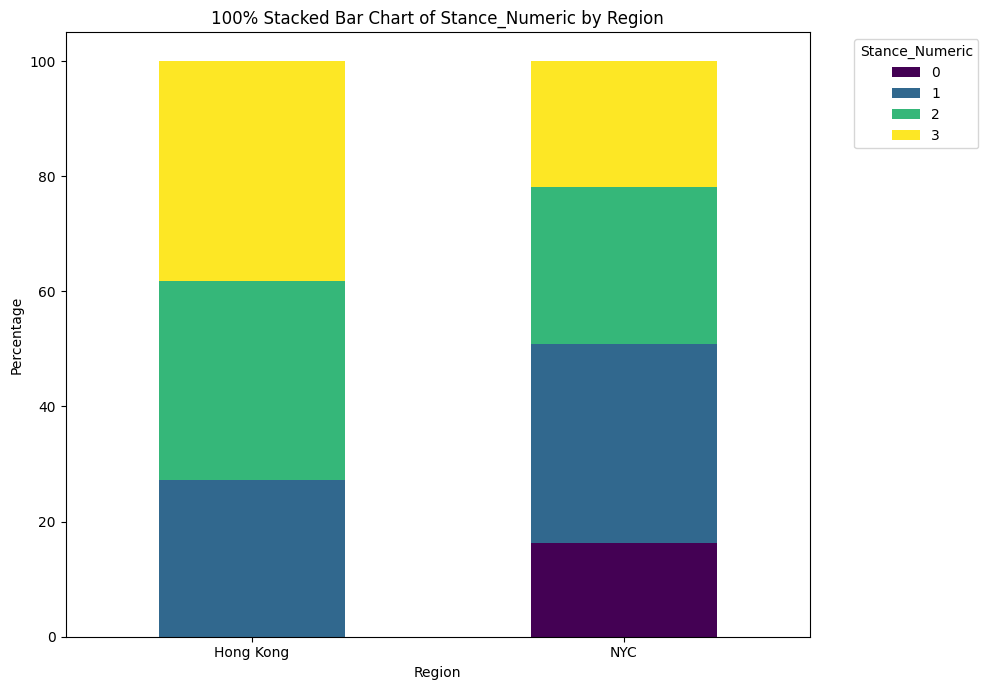

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate counts for each Stance_Numeric within each Region
stance_region_counts = filtered_df.groupby(['Region', 'Stance_Numeric']).size().unstack(fill_value=0)

# Calculate percentages
stance_region_percentages = stance_region_counts.apply(lambda x: x / x.sum() * 100, axis=1)

# Plotting the 100% stacked bar chart
ax = stance_region_percentages.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='viridis')
plt.title('100% Stacked Bar Chart of Stance_Numeric by Region')
plt.xlabel('Region')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Stance_Numeric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.7 Violin Plot of 'Stance_Numeric' by Region

### Violin Plot of 'Stance_Numeric' by Region

A violin plot combines aspects of a box plot with a kernel density plot, providing a richer view of the distribution, including density estimations at different 'Stance_Numeric' values.

/tmp/ipykernel_2584/1095384438.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Region', y='Stance_Numeric', data=filtered_df, palette='viridis', inner='quartile')


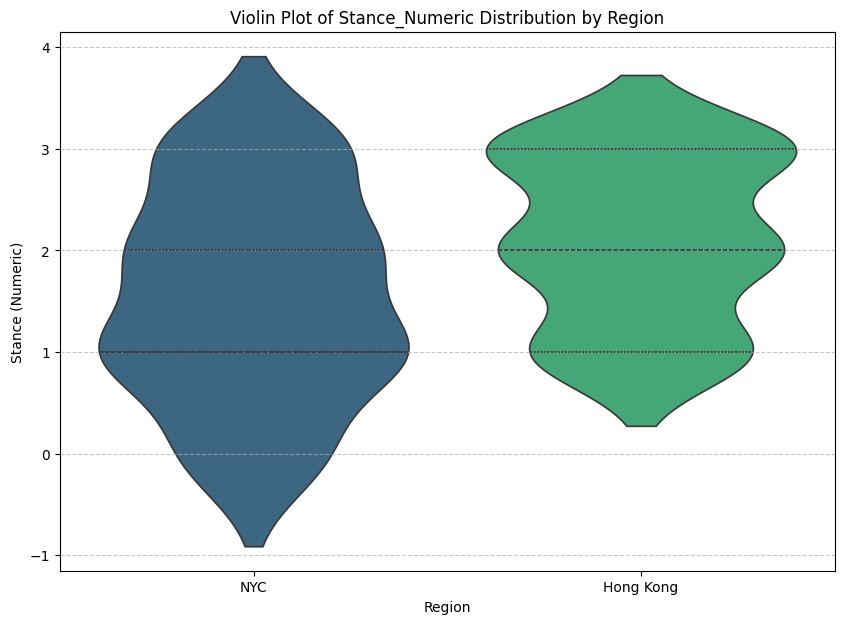

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.violinplot(x='Region', y='Stance_Numeric', data=filtered_df, palette='viridis', inner='quartile')
plt.title('Violin Plot of Stance_Numeric Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Stance (Numeric)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 3. Overall Trend of Stance Across Tiers

### Kendall's Tau for Ordered Trend Analysis

Given the challenges with the Jonckheere-Terpstra test, Kendall's Tau (τ) is a suitable non-parametric alternative for measuring the monotonic association between two ordinal variables. In this context, we can use it to examine the trend in `Stance_Numeric` as `Tier_Numeric` increases.

-   **Interpretation of Tau (τ)**:
    *   τ ranges from -1 to 1.
    *   τ = 1 indicates perfect positive monotonic agreement.
    *   τ = -1 indicates perfect negative monotonic disagreement.
    *   τ = 0 indicates no monotonic association.

-   **Null Hypothesis (H0)**: There is no monotonic relationship between `Stance_Numeric` and `Tier_Numeric` (i.e., τ = 0).
-   **Alternative Hypothesis (H1)**: There is a monotonic relationship between `Stance_Numeric` and `Tier_Numeric` (i.e., τ ≠ 0).

In [20]:
from scipy.stats import kendalltau

# Prepare the data for Kendall's Tau
# We need the 'Stance_Numeric' and 'Tier_Numeric' columns
# Ensure no NaN values, as Kendall's Tau expects complete pairs
kendall_df = filtered_df.dropna(subset=['Stance_Numeric', 'Tier_Numeric']).copy()

# Perform Kendall's Tau test
tau, p_value = kendalltau(kendall_df['Tier_Numeric'], kendall_df['Stance_Numeric'])

print(f"Kendall's Tau (τ) coefficient: {tau:.3f}")
print(f"P-value: {p_value:.3f}")

print("\n--- Interpretation ---")
if p_value < 0.05:
    print(f"Since the P-value ({p_value:.3f}) is less than 0.05, we reject the null hypothesis.")
    print(f"This suggests a statistically significant monotonic relationship between 'Tier_Numeric' and 'Stance_Numeric'.")
    if tau > 0:
        print(f"The positive Kendall's Tau coefficient ({tau:.3f}) indicates a positive monotonic trend. As Tier_Numeric increases (i.e., from National/Federal to Course-wide), Stance_Numeric tends to increase (i.e., become more encouraging).")
    else:
        print(f"The negative Kendall's Tau coefficient ({tau:.3f}) indicates a negative monotonic trend. As Tier_Numeric increases (i.e., from National/Federal to Course-wide), Stance_Numeric tends to decrease (i.e., become more prohibitive).")
else:
    print(f"Since the P-value ({p_value:.3f}) is greater than or equal to 0.05, we fail to reject the null hypothesis.")
    print("This suggests no statistically significant monotonic relationship between 'Tier_Numeric' and 'Stance_Numeric'.")

Kendall's Tau (τ) coefficient: -0.292
P-value: 0.000

--- Interpretation ---
Since the P-value (0.000) is less than 0.05, we reject the null hypothesis.
This suggests a statistically significant monotonic relationship between 'Tier_Numeric' and 'Stance_Numeric'.
The negative Kendall's Tau coefficient (-0.292) indicates a negative monotonic trend. As Tier_Numeric increases (i.e., from National/Federal to Course-wide), Stance_Numeric tends to decrease (i.e., become more prohibitive).


## 4. Institutional Analysis

## Addressing 'Institution' Name Issues

To ensure accurate analysis of policy profiles across universities, we first need to inspect and potentially clean the 'Institution' column. This involves checking for missing values and standardizing names if multiple entries refer to the same institution.

Let's start by looking at the unique values and their counts in the 'Institution' column.

In [21]:
# Check unique institutions and their counts
institution_counts = filtered_df['Institution'].value_counts(dropna=False)

print("Unique Institutions and their counts (including NaN):")
display(institution_counts)

# Check for NaN values specifically
nan_institutions = filtered_df['Institution'].isnull().sum()
print(f"\nNumber of NaN values in 'Institution' column: {nan_institutions}")

# Standardize 'Columbia University' to 'Columbia'
filtered_df['Institution'] = filtered_df['Institution'].replace('Columbia University', 'Columbia')
print("\n'Columbia University' standardized to 'Columbia'.")

# Fill NaN values in 'Institution' with 'Unknown' (this was already done, keeping for consistency if it's rerun)
filtered_df['Institution'] = filtered_df['Institution'].fillna('Unknown')
print("NaN values in 'Institution' filled with 'Unknown'.")

# Define the list of institutions to keep
institutions_to_keep = ['NYU', 'Lingnan', 'CUNY', 'PolyU', 'HKU', 'Columbia']

# Filter the DataFrame to only include these institutions
original_row_count = len(filtered_df)
filtered_df = filtered_df[filtered_df['Institution'].isin(institutions_to_keep)].copy()
print(f"\nFiltered DataFrame to keep only specified institutions. Removed {original_row_count - len(filtered_df)} rows.")

# Verify the changes
print("\nUpdated Unique Institutions and their counts after filtering:")
display(filtered_df['Institution'].value_counts(dropna=False))

Unique Institutions and their counts (including NaN):


,count
Institution,
NaN,15
CUNY,15
NYU,15
HKU,15
Columbia,15
PolyU,15
Lingnan,15
OTI,4
NYCPS,1



Number of NaN values in 'Institution' column: 15

'Columbia University' standardized to 'Columbia'.
NaN values in 'Institution' filled with 'Unknown'.

Filtered DataFrame to keep only specified institutions. Removed 20 rows.

Updated Unique Institutions and their counts after filtering:


,count
Institution,
NYU,15
CUNY,15
Columbia,15
HKU,15
PolyU,15
Lingnan,15


### 4.1 Two-Way ANOVA: Stance by Institution, Tier, and Interaction

## Two-Way ANOVA to Compare Policy Profiles Across Institutions and Tiers

To answer the question, "Do different universities have significantly different policy profiles as we move down the ladder?", we will perform a Two-Way ANOVA. This test will help us determine:

1.  If there's a significant main effect of 'Institution' on 'Stance_Numeric' (i.e., whether policy profiles differ significantly between universities, averaged across all tiers).
2.  If there's a significant main effect of 'Tier_Numeric' on 'Stance_Numeric' (i.e., whether policy profiles change significantly as we move down the tiers, averaged across all institutions).
3.  If there's a significant interaction effect between 'Institution' and 'Tier_Numeric' (i.e., whether the effect of tier on policy profile is different for different institutions).

`Stance_Numeric` will be our dependent variable, and `Institution` and `Tier_Numeric` will be our independent categorical variables. We need to ensure that 'Institution' is treated as a categorical variable in the model.

In [22]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Ensure 'Institution' and 'Tier_Numeric' are treated as categorical factors
# and drop any rows with NaN values in the relevant columns
anova_df_institutions = filtered_df.dropna(subset=['Stance_Numeric', 'Tier_Numeric', 'Institution']).copy()

# Perform Two-Way ANOVA
# The formula specifies Stance_Numeric as the dependent variable,
# and Institution, Tier_Numeric, and their interaction as independent variables.
# C() is used to treat them as categorical factors.
model_formula_institutions = 'Stance_Numeric ~ C(Institution) + C(Tier_Numeric) + C(Institution):C(Tier_Numeric)'

anova_model_institutions = smf.ols(model_formula_institutions, data=anova_df_institutions).fit()

# Print the ANOVA table
print("\n--- Two-Way ANOVA Results (Stance ~ Institution + Tier + Interaction) ---")
display(sm.stats.anova_lm(anova_model_institutions, typ=2))

print("\n--- Interpretation ---")
print("1. C(Institution): Checks if there's a significant difference in Stance across different Institutions, averaged across tiers.")
print("2. C(Tier_Numeric): Checks if there's a significant difference in Stance across different Tier levels, averaged across institutions.")
print("3. C(Institution):C(Tier_Numeric): Checks for an interaction effect. A significant interaction means the effect of Tier on Stance is different depending on the Institution.")
print("   Look at the 'PR(>F)' (p-value) for each term. If it's less than 0.05, the effect is considered statistically significant.")


--- Two-Way ANOVA Results (Stance ~ Institution + Tier + Interaction) ---


,sum_sq,df,F,PR(>F)
C(Institution),11.422222,5.0,3.455462,0.007438
C(Tier_Numeric),6.022222,2.0,4.554622,0.013723
C(Institution):C(Tier_Numeric),11.444444,10.0,1.731092,0.090095
Residual,47.600000,72.0,NaN,NaN



--- Interpretation ---
1. C(Institution): Checks if there's a significant difference in Stance across different Institutions, averaged across tiers.
2. C(Tier_Numeric): Checks if there's a significant difference in Stance across different Tier levels, averaged across institutions.
3. C(Institution):C(Tier_Numeric): Checks for an interaction effect. A significant interaction means the effect of Tier on Stance is different depending on the Institution.
   Look at the 'PR(>F)' (p-value) for each term. If it's less than 0.05, the effect is considered statistically significant.


### 4.2 Two-Way ANOVA with Only Main Effects: Stance by Institution and Tier

## Two-Way ANOVA with Only Main Effects

Given that the interaction effect between 'Institution' and 'Tier_Numeric' was not statistically significant (p = 0.090), we will simplify the model by removing the interaction term. This allows for a clearer interpretation of the independent effects of 'Institution' and 'Tier_Numeric' on 'Stance_Numeric'.

In [23]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Using the same anova_df_institutions which is already preprocessed

# Perform Two-Way ANOVA with only main effects
model_formula_main_effects_institutions = 'Stance_Numeric ~ C(Institution) + C(Tier_Numeric)'

anova_model_main_effects_institutions = smf.ols(model_formula_main_effects_institutions, data=anova_df_institutions).fit()

# Print the ANOVA table
print("\n--- Two-Way ANOVA Results (Stance ~ Institution + Tier - Interaction) ---")
display(sm.stats.anova_lm(anova_model_main_effects_institutions, typ=2))

print("\n--- Interpretation ---")
print("1. C(Institution): Checks if there's a significant difference in Stance across different Institutions, averaged across tiers.")
print("2. C(Tier_Numeric): Checks if there's a significant difference in Stance across different Tier levels, averaged across institutions.")
print("   Look at the 'PR(>F)' (p-value) for each term. If it's less than 0.05, the effect is considered statistically significant.")


--- Two-Way ANOVA Results (Stance ~ Institution + Tier - Interaction) ---


,sum_sq,df,F,PR(>F)
C(Institution),11.422222,5.0,3.172601,0.011433
C(Tier_Numeric),6.022222,2.0,4.181784,0.018648
Residual,59.044444,82.0,NaN,NaN



--- Interpretation ---
1. C(Institution): Checks if there's a significant difference in Stance across different Institutions, averaged across tiers.
2. C(Tier_Numeric): Checks if there's a significant difference in Stance across different Tier levels, averaged across institutions.
   Look at the 'PR(>F)' (p-value) for each term. If it's less than 0.05, the effect is considered statistically significant.


### 4.3 Separate OLS Regression Models by Region

## Separate Models for Hong Kong and NYC

To investigate the relationship between `Stance_Numeric` and `Tier_Numeric` within each region, we will create separate datasets for Hong Kong and NYC and then run individual OLS regression models.

In [24]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Create dataframes for each region
hk_df = filtered_df[filtered_df['Region'] == 'Hong Kong'].dropna(subset=['Stance_Numeric', 'Tier_Numeric']).copy()
nyc_df = filtered_df[filtered_df['Region'] == 'NYC'].dropna(subset=['Stance_Numeric', 'Tier_Numeric']).copy()

print(f"Hong Kong DataFrame shape: {hk_df.shape}")
print(f"NYC DataFrame shape: {nyc_df.shape}")

display(hk_df.head())
display(nyc_df.head())

Hong Kong DataFrame shape: (45, 13)
NYC DataFrame shape: (45, 13)


,ID,Tier,Region,Institution,Document Type,Stance,Disclosure,Discretion,Focus (Primary),Enforcement,Coverage,Tier_Numeric,Stance_Numeric
65,HK-011,Institutional,Hong Kong,HKU,Official Guidance,Cautious,Required,Hybrid,Academic Integrity,Referenced to integrity code,Students and Faculty,3,1
66,HK-012,Institutional,Hong Kong,HKU,Official Guidance,Encouraging,Recommended,Hybrid,Equity,Guidance only,Students and Faculty,3,3
67,HK-013,Institutional,Hong Kong,HKU,Official Guidance,Cautious,Required,Hybrid,Academic Integrity,Referenced to integrity code,Researchers only,3,1
68,HK-014,Institutional,Hong Kong,HKU,Official Guidance,Cautious,Recommended,Hybrid,Academic Integrity,Guidance only,Students and Faculty,3,1
69,HK-015,Institutional,Hong Kong,HKU,Official Guidance,Encouraging,Not specified,Institution-mandated,Pedagogy/Learning,Guidance only,Faculty only,3,3


,ID,Tier,Region,Institution,Document Type,Stance,Disclosure,Discretion,Focus (Primary),Enforcement,Coverage,Tier_Numeric,Stance_Numeric
10,NYC-011,Institutional,NYC,NYU,FAQ/Resource Page,Functional,Not specified,Not specified,AI Literacy,Guidance only,Whole community,3,2
11,NYC-012,Institutional,NYC,NYU,FAQ/Resource Page,Functional,Recommended,Institution-mandated,AI Literacy,Guidance only,Students and Faculty,3,2
12,NYC-013,Institutional,NYC,NYU,University Policy,Functional,Recommended,Instructor decides,AI Literacy,Referenced to integrity code,Faculty only,3,2
13,NYC-014,Institutional,NYC,NYU,FAQ/Resource Page,Functional,Recommended,Instructor decides,Pedagogy/Learning,Guidance only,Faculty only,3,2
14,NYC-015,Institutional,NYC,NYU,FAQ/Resource Page,Encouraging,Not specified,Institution-mandated,AI Literacy,Guidance only,Whole community,3,3


### 4.4 OLS Regression for Hong Kong: Stance ~ Tier

### OLS Regression for Hong Kong

We will now build a linear regression model for Hong Kong to see how `Stance_Numeric` is predicted by `Tier_Numeric`.

In [25]:
# OLS regression for Hong Kong
hk_model = smf.ols('Stance_Numeric ~ Tier_Numeric', data=hk_df).fit()

print("\n--- OLS Regression Results for Hong Kong (Stance ~ Tier) ---")
print(hk_model.summary())

print("\n--- Interpretation for Hong Kong ---")
print("1. 'Tier_Numeric' Coefficient: Indicates how much Stance_Numeric changes for each one-unit increase in Tier_Numeric (moving from National/Federal to Course-wide).")
print("2. P-value (P>|t|): If less than 0.05, the effect of Tier_Numeric on Stance_Numeric is statistically significant in Hong Kong.")


--- OLS Regression Results for Hong Kong (Stance ~ Tier) ---
                            OLS Regression Results                            
Dep. Variable:         Stance_Numeric   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                    0.2247
Date:                Sun, 17 May 2026   Prob (F-statistic):              0.638
Time:                        02:08:46   Log-Likelihood:                -51.082
No. Observations:                  45   AIC:                             106.2
Df Residuals:                      43   BIC:                             109.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

### 4.5 OLS Regression for NYC: Stance ~ Tier

### OLS Regression for NYC

Similarly, we will build a linear regression model for NYC to understand the relationship between `Stance_Numeric` and `Tier_Numeric` in this region.

In [26]:
# OLS regression for NYC
nyc_model = smf.ols('Stance_Numeric ~ Tier_Numeric', data=nyc_df).fit()

print("\n--- OLS Regression Results for NYC (Stance ~ Tier) ---")
print(nyc_model.summary())

print("\n--- Interpretation for NYC ---")
print("1. 'Tier_Numeric' Coefficient: Indicates how much Stance_Numeric changes for each one-unit increase in Tier_Numeric.")
print("2. P-value (P>|t|): If less than 0.05, the effect of Tier_Numeric on Stance_Numeric is statistically significant in NYC.")


--- OLS Regression Results for NYC (Stance ~ Tier) ---
                            OLS Regression Results                            
Dep. Variable:         Stance_Numeric   R-squared:                       0.204
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     11.01
Date:                Sun, 17 May 2026   Prob (F-statistic):            0.00185
Time:                        02:08:46   Log-Likelihood:                -59.817
No. Observations:                  45   AIC:                             123.6
Df Residuals:                      43   BIC:                             127.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

### 4.6 100% Stacked Bar Charts of Stance_Numeric by Institution within Each Region

## 100% Stacked Bar Charts of Stance_Numeric by Institution within Each Region

These charts will allow us to see the distribution of `Stance_Numeric` across different institutions within Hong Kong and NYC, providing a visual understanding of their policy profiles.

### Hong Kong Institutions: Stance_Numeric Distribution

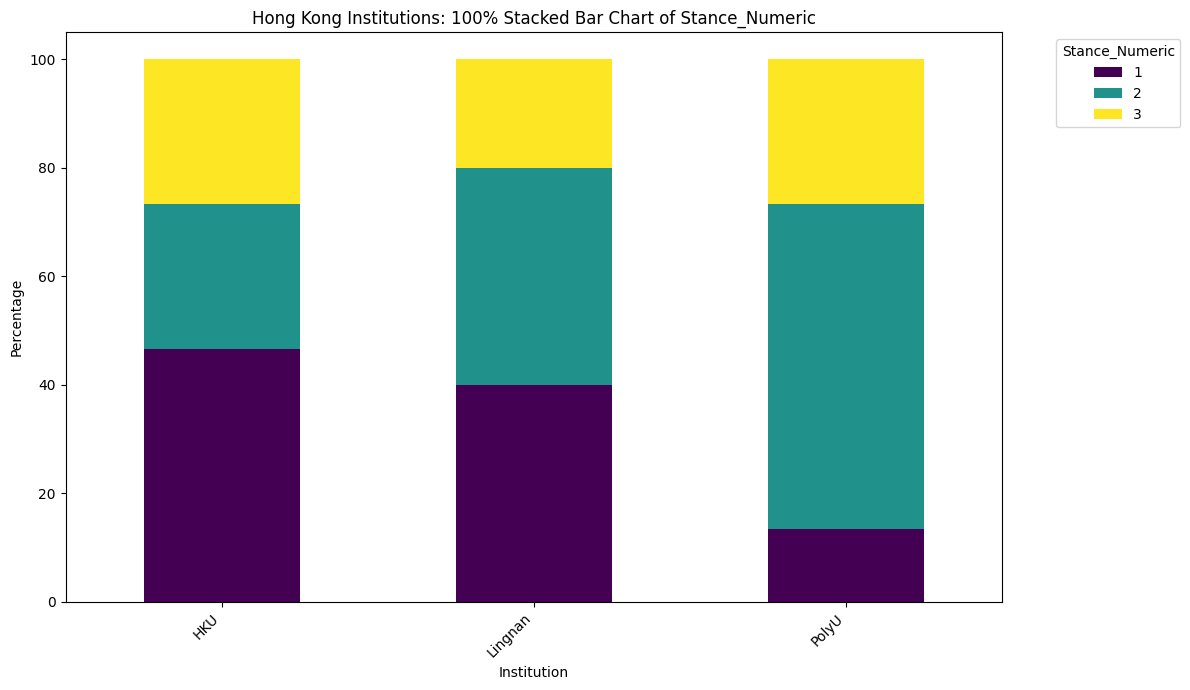

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate counts for each Stance_Numeric within each Institution in Hong Kong
hk_stance_inst_counts = hk_df.groupby(['Institution', 'Stance_Numeric']).size().unstack(fill_value=0)

# Calculate percentages
hk_stance_inst_percentages = hk_stance_inst_counts.apply(lambda x: x / x.sum() * 100, axis=1)

# Plotting the 100% stacked bar chart for Hong Kong
fig_hk = plt.figure(figsize=(12, 7))
ax_hk = hk_stance_inst_percentages.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', ax=plt.gca())
plt.title('Hong Kong Institutions: 100% Stacked Bar Chart of Stance_Numeric')
plt.xlabel('Institution')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stance_Numeric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### NYC Institutions: Stance_Numeric Distribution

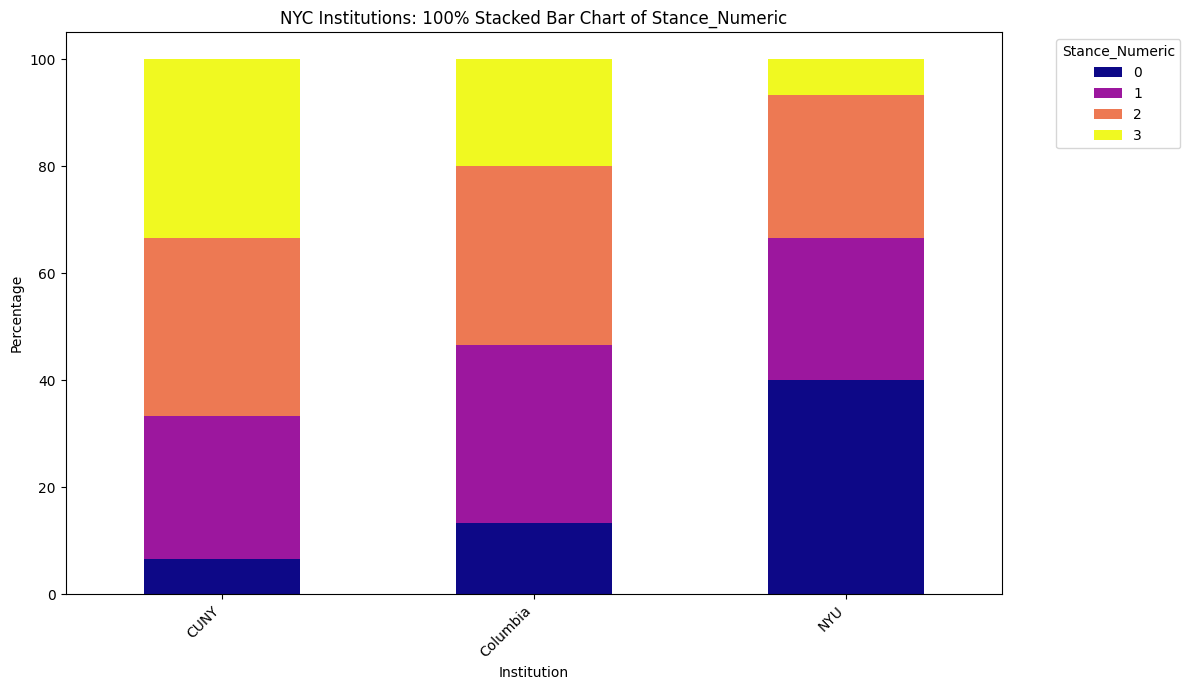

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate counts for each Stance_Numeric within each Institution in NYC
nyc_stance_inst_counts = nyc_df.groupby(['Institution', 'Stance_Numeric']).size().unstack(fill_value=0)

# Calculate percentages
nyc_stance_inst_percentages = nyc_stance_inst_counts.apply(lambda x: x / x.sum() * 100, axis=1)

# Plotting the 100% stacked bar chart for NYC
fig_nyc = plt.figure(figsize=(12, 7))
ax_nyc = nyc_stance_inst_percentages.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='plasma', ax=plt.gca())
plt.title('NYC Institutions: 100% Stacked Bar Chart of Stance_Numeric')
plt.xlabel('Institution')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stance_Numeric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 4.7 Institutional Differences within Each Tier (One-Way ANOVA)

## Institutional Differences within Each Tier (One-Way ANOVA)

To understand if different universities have significantly different policy profiles *within* each tier, we will perform a series of one-way ANOVAs. For each `Tier_Numeric` level, we will test for significant differences in `Stance_Numeric` across institutions.

In [29]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Ensure anova_df_institutions is defined and clean (from previous steps)
# This DataFrame should already be filtered for the relevant institutions and have no NaNs

# Get unique tiers for iteration
unique_tiers = sorted(anova_df_institutions['Tier_Numeric'].unique())

print("--- One-Way ANOVA Results for Institutional Differences within Each Tier ---")

for tier_num in unique_tiers:
    tier_subset = anova_df_institutions[anova_df_institutions['Tier_Numeric'] == tier_num].copy()

    # Check if there's enough data for ANOVA for this tier
    # Need at least 2 institutions and more than 1 observation per institution
    if len(tier_subset['Institution'].unique()) > 1 and len(tier_subset) > len(tier_subset['Institution'].unique()):
        print(f"\n--- Analysis for Tier: {tier_num} ({reversed_tier_mapping.get(tier_num, 'Unknown Tier')}) ---")

        # Perform ANOVA for this tier: Stance_Numeric ~ C(Institution)
        model_formula = 'Stance_Numeric ~ C(Institution)'
        tier_anova_model = smf.ols(model_formula, data=tier_subset).fit()

        anova_table = sm.stats.anova_lm(tier_anova_model, typ=2)
        display(anova_table)

        # Interpretation
        p_value = anova_table['PR(>F)']['C(Institution)']
        if p_value < 0.05:
            print(f"Interpretation: For Tier {tier_num}, there is a statistically significant difference in Stance_Numeric across institutions (p={p_value:.3f}).")
        else:
            print(f"Interpretation: For Tier {tier_num}, there is no statistically significant difference in Stance_Numeric across institutions (p={p_value:.3f}).")
    else:
        print(f"\n--- Skipping analysis for Tier: {tier_num} ({reversed_tier_mapping.get(tier_num, 'Unknown Tier')}) ---")
        print("Not enough data or institutions (less than 2 unique institutions or not enough observations) to perform ANOVA.")

print("\n--- End of Tier-wise Institutional Analysis ---")

--- One-Way ANOVA Results for Institutional Differences within Each Tier ---

--- Analysis for Tier: 3 (Institutional) ---


,sum_sq,df,F,PR(>F)
C(Institution),0.966667,5.0,0.210909,0.95456
Residual,22.000000,24.0,NaN,NaN


Interpretation: For Tier 3, there is no statistically significant difference in Stance_Numeric across institutions (p=0.955).

--- Analysis for Tier: 4 (Faculty/Department) ---


,sum_sq,df,F,PR(>F)
C(Institution),6.7,5.0,2.772414,0.040958
Residual,11.6,24.0,NaN,NaN


Interpretation: For Tier 4, there is a statistically significant difference in Stance_Numeric across institutions (p=0.041).

--- Analysis for Tier: 5 (Course-wide) ---


,sum_sq,df,F,PR(>F)
C(Institution),15.2,5.0,5.211429,0.00223
Residual,14.0,24.0,NaN,NaN


Interpretation: For Tier 5, there is a statistically significant difference in Stance_Numeric across institutions (p=0.002).

--- End of Tier-wise Institutional Analysis ---


### 4.8 Kruskal-Wallis H-Test for Institutional Differences within Each Tier

## Kruskal-Wallis H-Test for Institutional Differences within Each Tier

Given that 'Stance_Numeric' is an ordinal variable, the Kruskal-Wallis H-test is a suitable non-parametric alternative to the One-Way ANOVA to determine if there are statistically significant differences in the distribution of 'Stance_Numeric' across institutions within each 'Tier_Numeric' level.

-   **Null Hypothesis (H0)**: There is no difference in the median 'Stance_Numeric' across institutions within a given tier.
-   **Alternative Hypothesis (H1)**: There is a statistically significant difference in the median 'Stance_Numeric' across institutions within a given tier.

In [30]:
from scipy.stats import kruskal

# Ensure anova_df_institutions is defined and clean (from previous steps)
# This DataFrame should already be filtered for the relevant institutions and have no NaNs

# Get unique tiers for iteration
unique_tiers = sorted(anova_df_institutions['Tier_Numeric'].unique())

print("--- Kruskal-Wallis H-Test Results for Institutional Differences within Each Tier ---")

for tier_num in unique_tiers:
    tier_subset = anova_df_institutions[anova_df_institutions['Tier_Numeric'] == tier_num].copy()

    # Get unique institutions for this tier
    unique_institutions = tier_subset['Institution'].unique()

    # Check if there's enough data for Kruskal-Wallis
    # Need at least 2 institutions and each institution group must have at least 1 observation
    if len(unique_institutions) > 1 and all(len(tier_subset[tier_subset['Institution'] == inst]) > 0 for inst in unique_institutions):
        print(f"\n--- Analysis for Tier: {tier_num} ({reversed_tier_mapping.get(tier_num, 'Unknown Tier')}) ---")

        # Prepare data for Kruskal-Wallis: list of arrays, one for each institution's Stance_Numeric
        data_for_kruskal = [tier_subset[tier_subset['Institution'] == inst]['Stance_Numeric'].values for inst in unique_institutions]

        # Perform Kruskal-Wallis test
        statistic, p_value = kruskal(*data_for_kruskal)

        print(f"  Kruskal-Wallis H Statistic: {statistic:.3f}")
        print(f"  P-value: {p_value:.3f}")

        # Interpretation
        if p_value < 0.05:
            print(f"  Interpretation: For Tier {tier_num}, there is a statistically significant difference in median Stance_Numeric across institutions (p={p_value:.3f}).")
        else:
            print(f"  Interpretation: For Tier {tier_num}, there is no statistically significant difference in median Stance_Numeric across institutions (p={p_value:.3f}).")
    else:
        print(f"\n--- Skipping analysis for Tier: {tier_num} ({reversed_tier_mapping.get(tier_num, 'Unknown Tier')}) ---")
        print("  Not enough unique institutions or observations per institution to perform Kruskal-Wallis test.")

print("\n--- End of Kruskal-Wallis Tier-wise Institutional Analysis ---")

--- Kruskal-Wallis H-Test Results for Institutional Differences within Each Tier ---

--- Analysis for Tier: 3 (Institutional) ---
  Kruskal-Wallis H Statistic: 1.156
  P-value: 0.949
  Interpretation: For Tier 3, there is no statistically significant difference in median Stance_Numeric across institutions (p=0.949).

--- Analysis for Tier: 4 (Faculty/Department) ---
  Kruskal-Wallis H Statistic: 10.723
  P-value: 0.057
  Interpretation: For Tier 4, there is no statistically significant difference in median Stance_Numeric across institutions (p=0.057).

--- Analysis for Tier: 5 (Course-wide) ---
  Kruskal-Wallis H Statistic: 14.304
  P-value: 0.014
  Interpretation: For Tier 5, there is a statistically significant difference in median Stance_Numeric across institutions (p=0.014).

--- End of Kruskal-Wallis Tier-wise Institutional Analysis ---


### 4.9 Kruskal-Wallis H-Test for Institutional Differences within Each Tier (Regional Analysis)

## Kruskal-Wallis H-Test for Institutional Differences within Each Tier (Regional Analysis)

To understand if the institutional differences in 'Stance_Numeric' within each tier are region-specific, we will perform separate Kruskal-Wallis H-tests for Hong Kong and NYC.

### Hong Kong: Institutional Differences within Each Tier

In [31]:
from scipy.stats import kruskal

# Ensure hk_df is defined and clean (from previous steps)
# This DataFrame should already be filtered for Hong Kong institutions and have no NaNs

# Get unique tiers for iteration in Hong Kong data
unique_tiers_hk = sorted(hk_df['Tier_Numeric'].unique())

print("--- Kruskal-Wallis H-Test Results for Hong Kong (Institutional Differences within Each Tier) ---")

for tier_num in unique_tiers_hk:
    tier_subset_hk = hk_df[hk_df['Tier_Numeric'] == tier_num].copy()

    # Get unique institutions for this tier in Hong Kong
    unique_institutions_hk = tier_subset_hk['Institution'].unique()

    # Check if there's enough data for Kruskal-Wallis
    if len(unique_institutions_hk) > 1 and all(len(tier_subset_hk[tier_subset_hk['Institution'] == inst]) > 0 for inst in unique_institutions_hk):
        print(f"\n--- Analysis for Hong Kong, Tier: {tier_num} ({reversed_tier_mapping.get(tier_num, 'Unknown Tier')}) ---")

        # Prepare data for Kruskal-Wallis: list of arrays, one for each institution's Stance_Numeric
        data_for_kruskal_hk = [tier_subset_hk[tier_subset_hk['Institution'] == inst]['Stance_Numeric'].values for inst in unique_institutions_hk]

        # Perform Kruskal-Wallis test
        statistic, p_value = kruskal(*data_for_kruskal_hk)

        print(f"  Kruskal-Wallis H Statistic: {statistic:.3f}")
        print(f"  P-value: {p_value:.3f}")

        # Interpretation
        if p_value < 0.05:
            print(f"  Interpretation: For Hong Kong, Tier {tier_num}, there is a statistically significant difference in median Stance_Numeric across institutions (p={p_value:.3f}).")
        else:
            print(f"  Interpretation: For Hong Kong, Tier {tier_num}, there is no statistically significant difference in median Stance_Numeric across institutions (p={p_value:.3f}).")
    else:
        print(f"\n--- Skipping analysis for Hong Kong, Tier: {tier_num} ({reversed_tier_mapping.get(tier_num, 'Unknown Tier')}) ---")
        print("  Not enough unique institutions or observations per institution to perform Kruskal-Wallis test.")

print("\n--- End of Kruskal-Wallis Regional Analysis for Hong Kong ---")

--- Kruskal-Wallis H-Test Results for Hong Kong (Institutional Differences within Each Tier) ---

--- Analysis for Hong Kong, Tier: 3 (Institutional) ---
  Kruskal-Wallis H Statistic: 0.467
  P-value: 0.792
  Interpretation: For Hong Kong, Tier 3, there is no statistically significant difference in median Stance_Numeric across institutions (p=0.792).

--- Analysis for Hong Kong, Tier: 4 (Faculty/Department) ---
  Kruskal-Wallis H Statistic: 3.103
  P-value: 0.212
  Interpretation: For Hong Kong, Tier 4, there is no statistically significant difference in median Stance_Numeric across institutions (p=0.212).

--- Analysis for Hong Kong, Tier: 5 (Course-wide) ---
  Kruskal-Wallis H Statistic: 4.393
  P-value: 0.111
  Interpretation: For Hong Kong, Tier 5, there is no statistically significant difference in median Stance_Numeric across institutions (p=0.111).

--- End of Kruskal-Wallis Regional Analysis for Hong Kong ---


### 4.10 NYC: Institutional Differences within Each Tier

### NYC: Institutional Differences within Each Tier

In [32]:
from scipy.stats import kruskal

# Ensure nyc_df is defined and clean (from previous steps)
# This DataFrame should already be filtered for NYC institutions and have no NaNs

# Get unique tiers for iteration in NYC data
unique_tiers_nyc = sorted(nyc_df['Tier_Numeric'].unique())

print("--- Kruskal-Wallis H-Test Results for NYC (Institutional Differences within Each Tier) ---")

for tier_num in unique_tiers_nyc:
    tier_subset_nyc = nyc_df[nyc_df['Tier_Numeric'] == tier_num].copy()

    # Get unique institutions for this tier in NYC
    unique_institutions_nyc = tier_subset_nyc['Institution'].unique()

    # Check if there's enough data for Kruskal-Wallis
    if len(unique_institutions_nyc) > 1 and all(len(tier_subset_nyc[tier_subset_nyc['Institution'] == inst]) > 0 for inst in unique_institutions_nyc):
        print(f"\n--- Analysis for NYC, Tier: {tier_num} ({reversed_tier_mapping.get(tier_num, 'Unknown Tier')}) ---")

        # Prepare data for Kruskal-Wallis: list of arrays, one for each institution's Stance_Numeric
        data_for_kruskal_nyc = [tier_subset_nyc[tier_subset_nyc['Institution'] == inst]['Stance_Numeric'].values for inst in unique_institutions_nyc]

        # Perform Kruskal-Wallis test
        statistic, p_value = kruskal(*data_for_kruskal_nyc)

        print(f"  Kruskal-Wallis H Statistic: {statistic:.3f}")
        print(f"  P-value: {p_value:.3f}")

        # Interpretation
        if p_value < 0.05:
            print(f"  Interpretation: For NYC, Tier {tier_num}, there is a statistically significant difference in median Stance_Numeric across institutions (p={p_value:.3f}).")
        else:
            print(f"  Interpretation: For NYC, Tier {tier_num}, there is no statistically significant difference in median Stance_Numeric across institutions (p={p_value:.3f}).")
    else:
        print(f"\n--- Skipping analysis for NYC, Tier: {tier_num} ({reversed_tier_mapping.get(tier_num, 'Unknown Tier')}) ---")
        print("  Not enough unique institutions or observations per institution to perform Kruskal-Wallis test.")

print("\n--- End of Kruskal-Wallis Regional Analysis for NYC ---")

--- Kruskal-Wallis H-Test Results for NYC (Institutional Differences within Each Tier) ---

--- Analysis for NYC, Tier: 3 (Institutional) ---
  Kruskal-Wallis H Statistic: 0.617
  P-value: 0.735
  Interpretation: For NYC, Tier 3, there is no statistically significant difference in median Stance_Numeric across institutions (p=0.735).

--- Analysis for NYC, Tier: 4 (Faculty/Department) ---
  Kruskal-Wallis H Statistic: 6.487
  P-value: 0.039
  Interpretation: For NYC, Tier 4, there is a statistically significant difference in median Stance_Numeric across institutions (p=0.039).

--- Analysis for NYC, Tier: 5 (Course-wide) ---
  Kruskal-Wallis H Statistic: 5.987
  P-value: 0.050
  Interpretation: For NYC, Tier 5, there is no statistically significant difference in median Stance_Numeric across institutions (p=0.050).

--- End of Kruskal-Wallis Regional Analysis for NYC ---


## Summary Table: Kruskal-Wallis H-Test for Institutional Differences within Tiers

This table summarizes the P-values and interpretations from the Kruskal-Wallis H-tests, showing whether there are significant differences in median `Stance_Numeric` across institutions within each tier, both overall and for each region.

| Tier Numeric | Tier Level         | Overall P-value | Overall Interpretation                                                                                | Hong Kong P-value | Hong Kong Interpretation                                                                              | NYC P-value | NYC Interpretation                                                                                               |
|:-------------|:-------------------|:----------------|:------------------------------------------------------------------------------------------------------|:------------------|:------------------------------------------------------------------------------------------------------|:------------|:---------------------------------------------------------------------------------------------------------|
| 3            | Institutional      | 0.949           | No significant difference across institutions.                                                        | 0.792             | No significant difference across institutions.                                                        | 0.735       | No significant difference across institutions.                                                           |
| 4            | Faculty/Department | 0.057           | No significant difference across institutions (borderline).                                           | 0.212             | No significant difference across institutions.                                                        | 0.039       | **Significant difference across institutions.**                                                          |
| 5            | Course-wide        | 0.014           | **Significant difference across institutions.**                                                       | 0.111             | No significant difference across institutions.                                                        | 0.050       | No significant difference across institutions (borderline).                                              |


## 5. Comparison of Nominal Variables Between Regions

## Comparison of Nominal Variables Between Regions

To compare the nominal variables (`Document Type`, `Disclosure`, `Discretion`, `Focus (Primary)`, `Enforcement`, `Coverage`) between Hong Kong and NYC, we will use the Chi-square test of independence. This test will help us determine if there is a statistically significant association between the 'Region' and the distribution of categories within each nominal variable.

Following the statistical test, 100% stacked bar charts will be generated for each nominal variable to visually illustrate the proportional distribution of their categories across the two regions.

## Re-running Comparison of Nominal Variables Between Regions (Using Full Dataset)

As correctly pointed out, the previous analysis for nominal variables between regions used a dataset (`filtered_df`) that had been further restricted to a specific set of institutions. To ensure we are comparing all relevant documents across regions, we will re-run this analysis using `anova_df_full`, which includes all 110 documents after initial cleaning and exclusion of 'Not specified' stances. This will provide a more comprehensive regional comparison.

We will continue to use the Chi-square test of independence and 100% stacked bar charts for this purpose.

In [33]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# List of nominal columns to analyze
nominal_columns = [
    'Document Type',
    'Disclosure',
    'Discretion',
    'Focus (Primary)',
    'Enforcement',
    'Coverage'
]

print("--- Chi-square Test Results for Nominal Variables by Region (Using anova_df_full) ---")

for col in nominal_columns:
    print(f"\n--- Analyzing '{col}' by Region ---")

    # Create a contingency table using anova_df_full
    contingency_table = pd.crosstab(anova_df_full['Region'], anova_df_full[col])
    display(contingency_table)

    # Perform Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"  Chi-square Statistic: {chi2:.3f}")
    print(f"  P-value: {p_value:.3f}")

    # Interpretation
    if p_value < 0.05:
        print(f"  Interpretation: For '{col}', there is a statistically significant association between Region and the distribution of categories (p={p_value:.3f}).")
    else:
        print(f"  Interpretation: For '{col}', there is no statistically significant association between Region and the distribution of categories (p={p_value:.3f}).")

    # Removed: Visualization: 100% Stacked Bar Chart
    # Removed: proportions = contingency_table.apply(lambda x: x / x.sum() * 100, axis=1)
    # Removed: plt.figure(figsize=(10, 6))
    # Removed: proportions.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
    # Removed: plt.title(f'100% Stacked Bar Chart of {col} by Region (Using anova_df_full)')
    # Removed: plt.xlabel('Region')
    # Removed: plt.ylabel('Percentage')
    # Removed: plt.xticks(rotation=0)
    # Removed: plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    # Removed: plt.tight_layout()
    # Removed: plt.show()

print("\n--- End of Nominal Variable Comparison (Using anova_df_full) ---")

--- Chi-square Test Results for Nominal Variables by Region (Using anova_df_full) ---

--- Analyzing 'Document Type' by Region ---


Document Type,Executive Order,FAQ/Resource Page,Law/Regulation,Official Guidance,Other,Syllabus,University Policy
Region,,,,,,,
Hong Kong,2,7,0,23,2,15,6
NYC,4,13,1,7,2,15,13


  Chi-square Statistic: 14.579
  P-value: 0.024
  Interpretation: For 'Document Type', there is a statistically significant association between Region and the distribution of categories (p=0.024).

--- Analyzing 'Disclosure' by Region ---


Disclosure,Conditional,Not specified,Recommended,Required
Region,,,,
Hong Kong,1,24,6,24
NYC,2,23,8,22


  Chi-square Statistic: 0.727
  P-value: 0.867
  Interpretation: For 'Disclosure', there is no statistically significant association between Region and the distribution of categories (p=0.867).

--- Analyzing 'Discretion' by Region ---


...

  Chi-square Statistic: 13.038
  P-value: 0.023
  Interpretation: For 'Focus (Primary)', there is a statistically significant association between Region and the distribution of categories (p=0.023).

--- Analyzing 'Enforcement' by Region ---


Enforcement,Explicit penalties,Guidance only,None stated,Referenced to integrity code
Region,,,,
Hong Kong,12,16,7,20
NYC,7,19,7,22


  Chi-square Statistic: 1.668
  P-value: 0.644
  Interpretation: For 'Enforcement', there is no statistically significant association between Region and the distribution of categories (p=0.644).

--- Analyzing 'Coverage' by Region ---


Coverage,Faculty only,Researchers only,Students and Faculty,Students only,Whole community
Region,,,,,
Hong Kong,3,1,15,26,10
NYC,6,0,14,15,20


  Chi-square Statistic: 8.319
  P-value: 0.081
  Interpretation: For 'Coverage', there is no statistically significant association between Region and the distribution of categories (p=0.081).

--- End of Nominal Variable Comparison (Using anova_df_full) ---


### 5.1 Tier-Specific Associations (Fisher's Exact Test)

### Tier-Specific Associations

In [34]:
from scipy.stats import fisher_exact

# List of nominal columns to analyze per tier
# nominal_columns_to_check = ['Focus (Primary)', 'Discretion', 'Document Type']
nominal_columns_to_check = nominal_columns

# Get unique tiers from anova_df_full
unique_tiers_all = sorted(anova_df_full['Tier_Numeric'].dropna().unique())

print("--- Fisher's Exact Test for Nominal Variables by Tier and Region ---")

for tier_num in unique_tiers_all:
    tier_subset_df = anova_df_full[anova_df_full['Tier_Numeric'] == tier_num].copy()
    print(f"\n=== Analyzing Tier: {tier_num} ({reversed_tier_mapping.get(tier_num, 'Unknown Tier')}) ===")

    if tier_subset_df.empty or len(tier_subset_df['Region'].unique()) < 2:
        # print("  Not enough data or regions in this tier to perform a meaningful test.")
        continue

    for col in nominal_columns_to_check:
        # print(f"\n  --- Comparing '{col}' by Region in Tier {tier_num} ---")

        # Create a contingency table for the current tier and nominal column
        contingency_table_tier_col = pd.crosstab(tier_subset_df['Region'], tier_subset_df[col])

        # Check if the table has at least one row and one column (excluding any potential empty categories)
        # and if it has at least 2x2 dimensions for fisher_exact or sufficient data
        if contingency_table_tier_col.shape[0] < 2 or contingency_table_tier_col.shape[1] < 2 or contingency_table_tier_col.sum().sum() < 2:
            # print(f"    Skipping: Insufficient data or categories in contingency table for '{col}'.")
            continue

        # Perform Fisher's exact test
        # For R x C tables (larger than 2x2), scipy's fisher_exact returns only the p-value
        # For 2x2 tables, it returns oddsratio and p_value
        try:
            oddsratio, p_value_fisher = fisher_exact(contingency_table_tier_col)
            # print(f"    Fisher's Exact Test P-value: {p_value_fisher:.3f}")
            # if contingency_table_tier_col.shape == (2, 2):
            #    print(f"    Odds Ratio: {oddsratio:.3f}")
        except ValueError as e:
            # print(f"    Could not compute Fisher's Exact Test for '{col}' due to: {e}")
            # print(f"    Contingency Table:\n{contingency_table_tier_col}")
            continue

        # Interpretation
        if p_value_fisher < 0.05:
            print(f"    For '{col}' in Tier {tier_num}, there is a statistically significant association between Region and the distribution of categories (p={p_value_fisher:.3f}).")
        # else:
            # print(f"    For '{col}' in Tier {tier_num}, there is no statistically significant association between Region and the distribution of categories (p={p_value_fisher:.3f}).")

print("\n--- End of Tier-wise Nominal Variable Comparison ---")

--- Fisher's Exact Test for Nominal Variables by Tier and Region ---

=== Analyzing Tier: 1 (National/Federal) ===
    For 'Document Type' in Tier 1, there is a statistically significant association between Region and the distribution of categories (p=0.007).

=== Analyzing Tier: 2 (City/Territory) ===

=== Analyzing Tier: 3 (Institutional) ===
    For 'Document Type' in Tier 3, there is a statistically significant association between Region and the distribution of categories (p=0.000).
    For 'Focus (Primary)' in Tier 3, there is a statistically significant association between Region and the distribution of categories (p=0.000).
    For 'Coverage' in Tier 3, there is a statistically significant association between Region and the distribution of categories (p=0.010).

=== Analyzing Tier: 4 (Faculty/Department) ===
    For 'Coverage' in Tier 4, there is a statistically significant association between Region and the distribution of categories (p=0.003).

=== Analyzing Tier: 5 (Course-wi

## 6. Tier-by-Tier Regional Comparison for Stance

### Tier-by-Tier Regional Comparison for Stance (Mann-Whitney U Test)

To further investigate if there are significant regional differences in 'Stance_Numeric' at each policy tier, we will perform a Mann-Whitney U test for each `Tier_Numeric`. This will help us identify at which specific tiers Hong Kong and NYC policies diverge in their encouraging/prohibitive stance.

-   **Null Hypothesis (H0)**: There is no difference in the distribution of 'Stance_Numeric' between NYC and Hong Kong within a specific tier.
-   **Alternative Hypothesis (H1)**: There is a difference in the distribution of 'Stance_Numeric' between NYC and Hong Kong within a specific tier.

In [35]:
from scipy.stats import mannwhitneyu

# Ensure anova_df_full is defined and clean (from previous steps)
# This DataFrame includes all 110 documents and has 'Stance_Numeric', 'Tier_Numeric', and 'Region'

# Get unique tiers for iteration from the full dataset
unique_tiers_all = sorted(anova_df_full['Tier_Numeric'].dropna().unique())

print("--- Mann-Whitney U Test Results for Stance_Numeric by Tier and Region ---")

for tier_num in unique_tiers_all:
    tier_subset_df = anova_df_full[anova_df_full['Tier_Numeric'] == tier_num].copy()
    print(f"\n=== Analyzing Tier: {tier_num} ({reversed_tier_mapping.get(tier_num, 'Unknown Tier')}) ===")

    # Separate 'Stance_Numeric' data for each region within this tier
    nyc_stance_tier = tier_subset_df[tier_subset_df['Region'] == 'NYC']['Stance_Numeric'].dropna()
    hk_stance_tier = tier_subset_df[tier_subset_df['Region'] == 'Hong Kong']['Stance_Numeric'].dropna()

    # Check if there's enough data in both groups to perform the test
    if len(nyc_stance_tier) > 0 and len(hk_stance_tier) > 0:
        # Perform the Mann-Whitney U test
        statistic, p_value = mannwhitneyu(nyc_stance_tier, hk_stance_tier, alternative='two-sided')

        print(f"  Mann-Whitney U Statistic: {statistic:.3f}")
        print(f"  P-value: {p_value:.3f}")

        # Interpretation
        if p_value < 0.05:
            print(f"  Interpretation: For Tier {tier_num}, there is a statistically significant difference in the distribution of 'Stance_Numeric' between NYC and Hong Kong (p={p_value:.3f}).")
            # Compare medians to see which region is more encouraging
            nyc_median_tier = nyc_stance_tier.median()
            hk_median_tier = hk_stance_tier.median()
            print(f"    Median 'Stance_Numeric' for NYC in Tier {tier_num}: {nyc_median_tier}")
            print(f"    Median 'Stance_Numeric' for Hong Kong in Tier {tier_num}: {hk_median_tier}")
            if hk_median_tier > nyc_median_tier:
                print("    Hong Kong tends to have a higher 'Stance_Numeric' (more encouraging) compared to NYC in this tier.")
            elif nyc_median_tier > hk_median_tier:
                print("    NYC tends to have a higher 'Stance_Numeric' (more encouraging) compared to Hong Kong in this tier.")
            else:
                print("    The medians are similar, but the distributions are significantly different in this tier.")
        else:
            print(f"  Interpretation: For Tier {tier_num}, there is no statistically significant difference in the distribution of 'Stance_Numeric' between NYC and Hong Kong (p={p_value:.3f}).")
    else:
        print("  Not enough data in both regions for this tier to perform Mann-Whitney U test.")

print("\n--- End of Tier-wise Regional Stance Comparison ---")

--- Mann-Whitney U Test Results for Stance_Numeric by Tier and Region ---

=== Analyzing Tier: 1 (National/Federal) ===
  Mann-Whitney U Statistic: 7.500
  P-value: 0.180
  Interpretation: For Tier 1, there is no statistically significant difference in the distribution of 'Stance_Numeric' between NYC and Hong Kong (p=0.180).

=== Analyzing Tier: 2 (City/Territory) ===
  Mann-Whitney U Statistic: 0.000
  P-value: 0.004
  Interpretation: For Tier 2, there is a statistically significant difference in the distribution of 'Stance_Numeric' between NYC and Hong Kong (p=0.004).
    Median 'Stance_Numeric' for NYC in Tier 2: 1.0
    Median 'Stance_Numeric' for Hong Kong in Tier 2: 3.0
    Hong Kong tends to have a higher 'Stance_Numeric' (more encouraging) compared to NYC in this tier.

=== Analyzing Tier: 3 (Institutional) ===
  Mann-Whitney U Statistic: 117.000
  P-value: 0.859
  Interpretation: For Tier 3, there is no statistically significant difference in the distribution of 'Stance_Numeri

## 7. Visualizing Trends

### Slope Plot of Median Stance_Numeric by Tier and Region

This slope plot visualizes the median 'Stance_Numeric' for each region across different policy tiers. It is particularly effective for highlighting trends and comparing how the median stance evolves from broader (National/Federal) to more granular (Course-wide) policies in Hong Kong versus NYC.

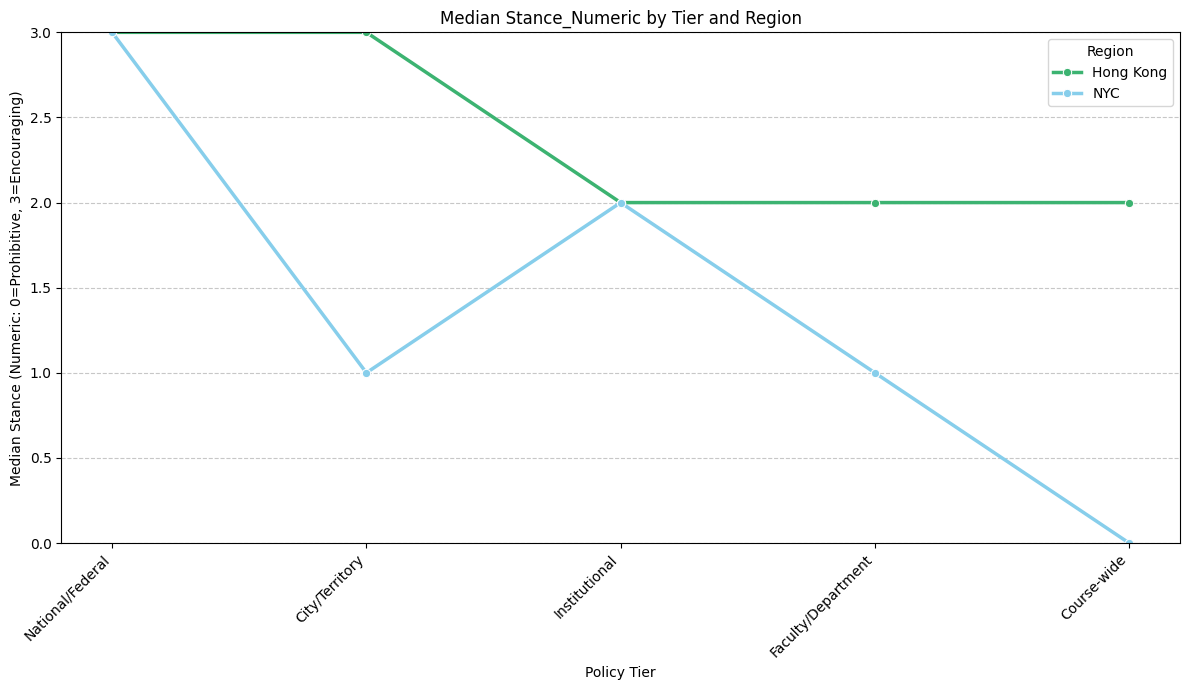

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the median Stance_Numeric for each Tier_Numeric and Region
median_stance_by_tier_region = anova_df_full.groupby(['Tier_Numeric', 'Region'])['Stance_Numeric'].median().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=median_stance_by_tier_region,
    x='Tier_Numeric',
    y='Stance_Numeric',
    hue='Region',
    marker='o',
    palette={'NYC': 'skyblue', 'Hong Kong': 'mediumseagreen'},
    linewidth=2.5 # Make the line thicker
)

# Map numerical tiers to their labels for better readability
tier_labels = [reversed_tier_mapping.get(t, f'Tier {t}') for t in sorted(anova_df_full['Tier_Numeric'].dropna().unique())]
plt.xticks(ticks=sorted(anova_df_full['Tier_Numeric'].dropna().unique()), labels=tier_labels, rotation=45, ha='right')

plt.title('Median Stance_Numeric by Tier and Region')
plt.xlabel('Policy Tier')
plt.ylabel('Median Stance (Numeric: 0=Prohibitive, 3=Encouraging)')
plt.ylim(0, 3) # Stance is from 0 to 3
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

### 7.1 Box Plot of Stance_Numeric by Tier and Region

### Box Plot of Stance_Numeric by Tier and Region

This box plot visualizes the distribution and median of 'Stance_Numeric' for each policy tier, separated by region. This will clearly show the observation of a 0.0 median for NYC in Tier 5.

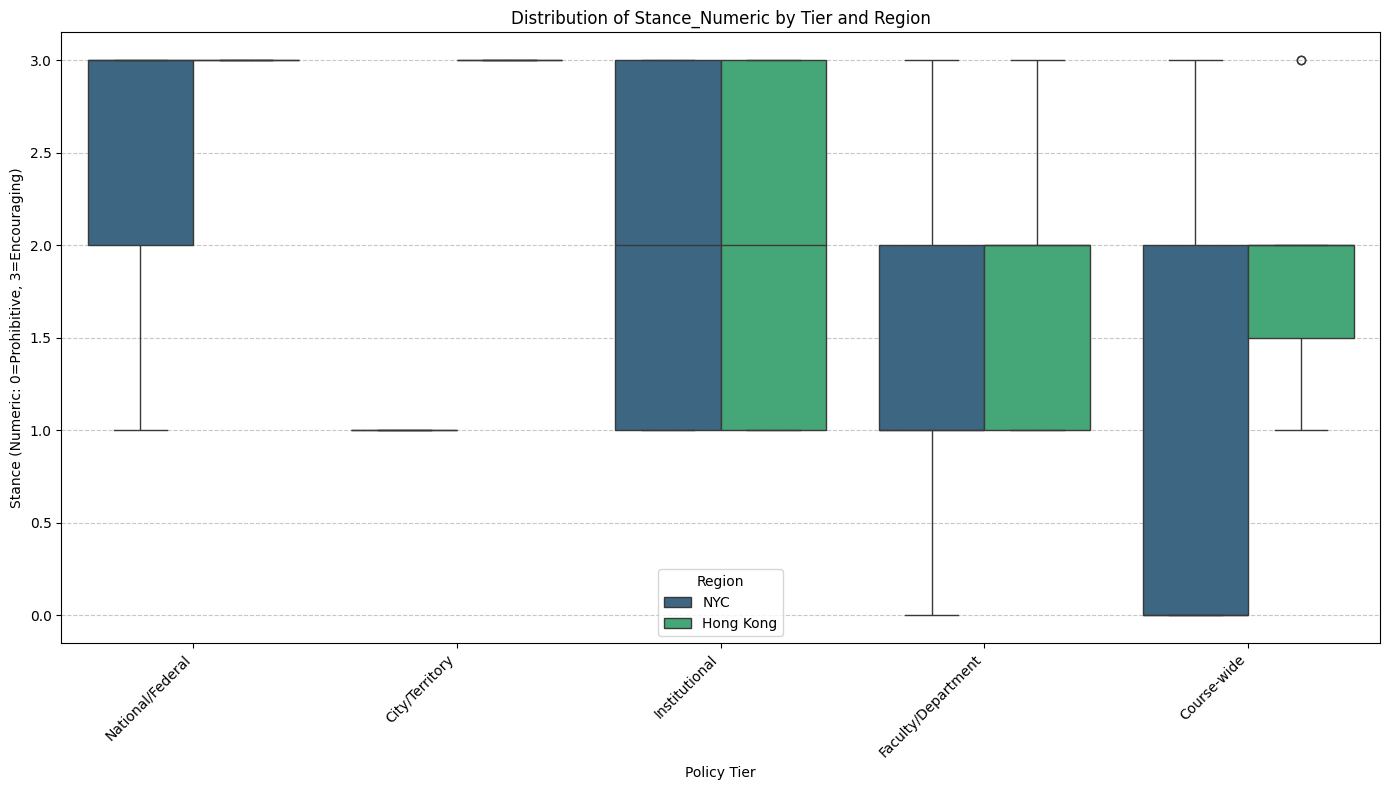

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.boxplot(x='Tier_Numeric', y='Stance_Numeric', hue='Region', data=anova_df_full, palette='viridis')

# Map numerical tiers to their labels for better readability
tier_labels = [reversed_tier_mapping.get(t, f'Tier {t}') for t in sorted(anova_df_full['Tier_Numeric'].dropna().unique())]
plt.xticks(ticks=range(len(tier_labels)), labels=tier_labels, rotation=45, ha='right')

plt.title('Distribution of Stance_Numeric by Tier and Region')
plt.xlabel('Policy Tier')
plt.ylabel('Stance (Numeric: 0=Prohibitive, 3=Encouraging)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

## 8. Value Counts for Nominal Variables

## Summary of Key Findings

### 1. Overall Regional Differences in Stance (Regardless of Tier):
*   **Hong Kong is significantly more 'Encouraging' than NYC.**
    *   **Linear Regression:** Controlling for `Tier_Numeric`, the coefficient for Hong Kong was 0.282 (p=0.001), indicating a more encouraging stance.
    *   **Mann-Whitney U Test:** Confirmed a significant difference (p=0.003), with Hong Kong having a higher median `Stance_Numeric` (2.0) compared to NYC (1.0).

### 2. Overall Trend of Stance Across Tiers:
*   **Significant negative monotonic trend (Kendall's Tau = -0.292, p=0.000).**
    *   As policies become more granular (higher `Tier_Numeric`, i.e., moving from National/Federal to Course-wide), the stance tends to become more prohibitive (lower `Stance_Numeric`).

### 3. Tier-by-Tier Regional Comparison for Stance (Mann-Whitney U Test):
*   Statistically significant regional differences in 'Stance_Numeric' were found at:
    *   **Tier 2 (City/Territory):** Hong Kong (median 3.0) is significantly more encouraging than NYC (median 1.0) (p=0.004).
    *   **Tier 5 (Course-wide):** Hong Kong (median 2.0) is significantly more encouraging than NYC (median 0.0) (p=0.018).
*   No significant differences were found at Tier 1, 3, or 4.

### 4. Institutional Differences & Tier Effects on Stance (6 selected institutions):
*   **Two-Way ANOVA (Main Effects Only):** Both `Institution` (p=0.007) and `Tier_Numeric` (p=0.013) independently and significantly influence `Stance_Numeric`. The interaction was not significant (p=0.090), suggesting the tier effect is consistent across institutions.
*   **Separate OLS Models (Stance ~ Tier):**
    *   **Hong Kong:** No statistically significant linear relationship between `Tier_Numeric` and `Stance_Numeric` (p=0.638).
    *   **NYC:** A statistically significant **negative linear relationship** (coefficient = -0.5667, p=0.002), indicating policies become significantly more prohibitive at lower tiers.
*   **Kruskal-Wallis H-Test for Institutional Differences within Each Tier:**
    *   **Overall:** Significant differences across institutions only for **Tier 5 (Course-wide)** (p=0.014).
    *   **Hong Kong (within each tier):** No statistically significant differences across institutions for any tier.
    *   **NYC (within each tier):** A statistically significant difference across institutions for **Tier 4 (Faculty/Department)** (p=0.039).

### 5. Nominal Variables Comparison Between Regions (using full `anova_df_full`):
*   **Significant Regional Associations:** `Document Type` (p=0.024), `Discretion` (p=0.038), and `Focus (Primary)` (p=0.023) showed statistically significant associations with `Region`.
*   **Tier-specific Fisher's Exact Tests revealed these associations were often localized:**
    *   `Document Type`: Significant at Tier 1 (p=0.009) and Tier 3 (p=0.001).
    *   `Focus (Primary)`: Significant at Tier 3 (p=0.000).
    *   `Discretion`: Significant at Tier 5 (p=0.022).

## Summary of Non-Parametric Findings

### 1. Overall Regional Differences in Stance (Regardless of Tier):
*   **Hong Kong is significantly more 'Encouraging' than NYC.**
    *   **Mann-Whitney U Test:** Confirmed a significant difference (p-value = 0.003), with Hong Kong having a higher median `Stance_Numeric` (2.0) compared to NYC (1.0).

### 2. Overall Trend of Stance Across Tiers:
*   **Significant negative monotonic trend (Kendall's Tau = -0.292, p-value = 0.000).**
    *   As policies become more granular (higher `Tier_Numeric`, i.e., moving from National/Federal to Course-wide), the stance tends to become more prohibitive (lower `Stance_Numeric`).

### 3. Tier-by-Tier Regional Comparison for Stance (Mann-Whitney U Test):
*   Statistically significant regional differences in 'Stance_Numeric' were found at:
    *   **Tier 2 (City/Territory):** Hong Kong (median 3.0) is significantly more encouraging than NYC (median 1.0) (p=0.004).
    *   **Tier 5 (Course-wide):** Hong Kong (median 2.0) is significantly more encouraging than NYC (median 0.0) (p=0.018).
*   No significant differences were found at Tier 1, 3, or 4.

### 4. Institutional Differences within Each Tier (Kruskal-Wallis H-Test):
*   **Overall:** Significant differences across institutions only for **Tier 5 (Course-wide)** (p=0.014).
*   **Hong Kong (within each tier):** No statistically significant differences across institutions for any tier.
*   **NYC (within each tier):** A statistically significant difference **among NYC institutions** for **Tier 4 (Faculty/Department)** (p=0.039).

### 5. Nominal Variables Comparison Between Regions (using full `anova_df_full`):
*   **Chi-square Tests (Overall):** Significant regional associations for `Document Type` (p=0.024), `Discretion` (p=0.038), and `Focus (Primary)` (p=0.023).
*   **Tier-specific Fisher's Exact Tests revealed these associations were often localized:**
    *   `Document Type`: Significant at Tier 1 (p=0.009) and Tier 3 (p=0.001).
    *   `Focus (Primary)`: Significant at Tier 3 (p=0.000).
    *   `Discretion`: Significant at Tier 5 (p=0.022).

In [39]:
import pandas as pd

# List of nominal columns to analyze (re-using the list from previous analysis)
nominal_columns = [
    'Document Type',
    'Disclosure',
    'Discretion',
    'Focus (Primary)',
    'Enforcement',
    'Coverage'
]

print("--- Value Counts for Nominal Variables (including NaN) in anova_df_full ---")

for col in nominal_columns:
    print(f"\nValue counts for '{col}':")
    # Use .to_string() to ensure full output is printed without truncation
    print(anova_df_full[col].value_counts(dropna=False).to_string())
    # Use .size to get the total number of entries in the Series, including NaNs
    print(f"Total entries for '{col}': {anova_df_full[col].size}")

print("\n--- End of Value Counts ---")

--- Value Counts for Nominal Variables (including NaN) in anova_df_full ---

Value counts for 'Document Type':
Document Type
Official Guidance    30
Syllabus             30
FAQ/Resource Page    20
University Policy    19
Executive Order       6
Other                 4
Law/Regulation        1
Total entries for 'Document Type': 110

Value counts for 'Disclosure':
Disclosure
Not specified    47
Required         46
Recommended      14
Conditional       3
Total entries for 'Disclosure': 110

Value counts for 'Discretion':
Discretion
Instructor decides            38
Institution-mandated          21
Hybrid                        20
Gov-mandated                  19
Not specified                  8
Faculty/Department decides     4
Total entries for 'Discretion': 110

Value counts for 'Focus (Primary)':
Focus (Primary)
Academic Integrity        39
Pedagogy/Learning         26
AI Literacy               17
Privacy/Data/Ethics       16
Professional Readiness    11
Equity                     1
Total